In [2]:
!pip install -q ultralytics
!pip install -q gradio pillow requests
print(" YOLOv8 installed!")

import ultralytics
ultralytics.checks()

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.4/107.7 GB disk)


In [3]:
#  Importing library for data manipulation
from ultralytics import YOLO
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

#  Load YOLOv8 Large Model
# YOLOv8l = large variant — best accuracy on T4 GPU
# Automatically downloads pretrained COCO weights (~87MB)
model = YOLO('yolov8l.pt')

#  Model Info
total_params = sum(p.numel() for p in model.model.parameters())
print("YOLOv8 Large loaded!")
print(f"Model parameters : {total_params:,}")
print(f"Total classes    : {len(model.names)} objects it can detect")

# Show first 20 detectable classes
print(f"\nFirst 20 detectable classes:")
for i, name in list(model.names.items())[:20]:
    print(f"  {i:3d}: {name}")

# Show all 80 classes
print(f"\nAll 80 COCO classes:")
print([name for name in model.names.values()])

YOLOv8 Large loaded!
Model parameters : 43,691,520
Total classes    : 80 objects it can detect

First 20 detectable classes:
    0: person
    1: bicycle
    2: car
    3: motorcycle
    4: airplane
    5: bus
    6: train
    7: truck
    8: boat
    9: traffic light
   10: fire hydrant
   11: stop sign
   12: parking meter
   13: bench
   14: bird
   15: cat
   16: dog
   17: horse
   18: sheep
   19: cow

All 80 COCO classes:
['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot 

In [4]:
# Helper Function to Display Results
def detect_and_display(image_url, title="Detection Result", conf=0.25):
    """
    Downloads an image, runs YOLOv8 detection,
    and displays the result with bounding boxes.
    """
    # Download image from URL
    response = requests.get(image_url, timeout=10)
    img = Image.open(BytesIO(response.content)).convert('RGB')
    img_np = np.array(img)

    # Run YOLOv8 inference
    results = model(img_np, conf=conf, verbose=False)

    # Get annotated image with bounding boxes
    annotated = results[0].plot()
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    # Count detections per class
    boxes = results[0].boxes
    detections = {}
    for box in boxes:
        cls_name = model.names[int(box.cls)]
        detections[cls_name] = detections.get(cls_name, 0) + 1

    # Display
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].imshow(img)
    axes[0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(annotated_rgb)
    axes[1].set_title(f"YOLOv8 Detections — {sum(detections.values())} objects found",
                      fontsize=12, fontweight='bold')
    axes[1].axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=150, bbox_inches='tight')
    plt.show()

    # Print detection summary
    print(f"\n Detection Summary — {title}")
    print(f"Total objects detected: {sum(detections.values())}")
    print("Objects found:")
    for obj, count in sorted(detections.items(), key=lambda x: -x[1]):
        print(f"  {obj}: {count}")

    return results

print(" Detection helper function ready!")

 Detection helper function ready!


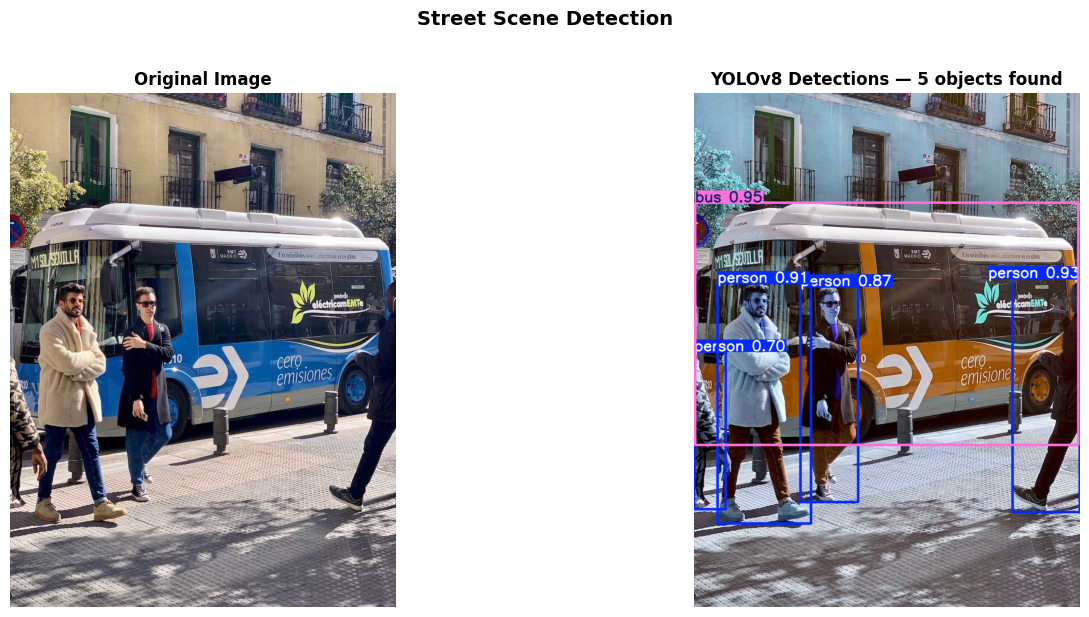


 Detection Summary — Street Scene Detection
Total objects detected: 5
Objects found:
  person: 4
  bus: 1


In [5]:
#Test 1: Street Scene
# Testing on a busy city street — expect people, cars, trucks
results1 = detect_and_display(
    "https://ultralytics.com/images/bus.jpg",
    title="Street Scene Detection"
)

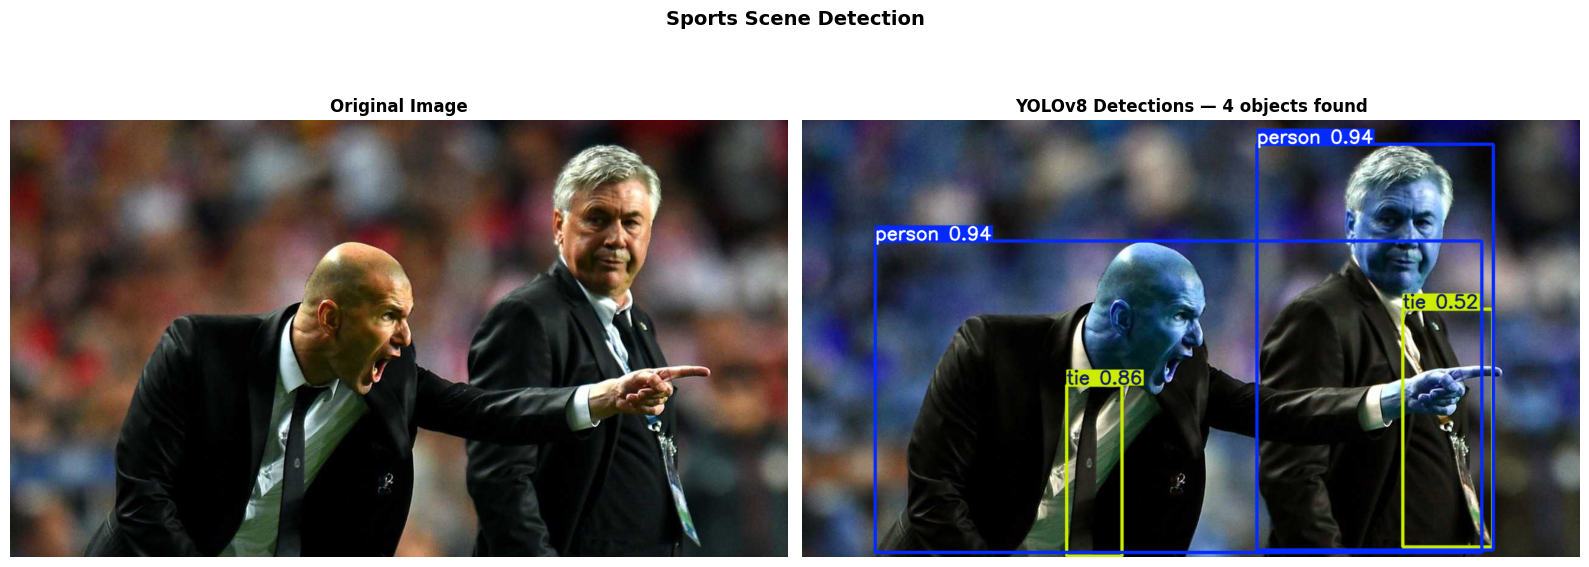


 Detection Summary — Sports Scene Detection
Total objects detected: 4
Objects found:
  person: 2
  tie: 2


In [6]:
# Test 2: Sports Scene
# Testing on a sports image — expect people, sports ball
results2 = detect_and_display(
    "https://ultralytics.com/images/zidane.jpg",
    title="Sports Scene Detection"
)

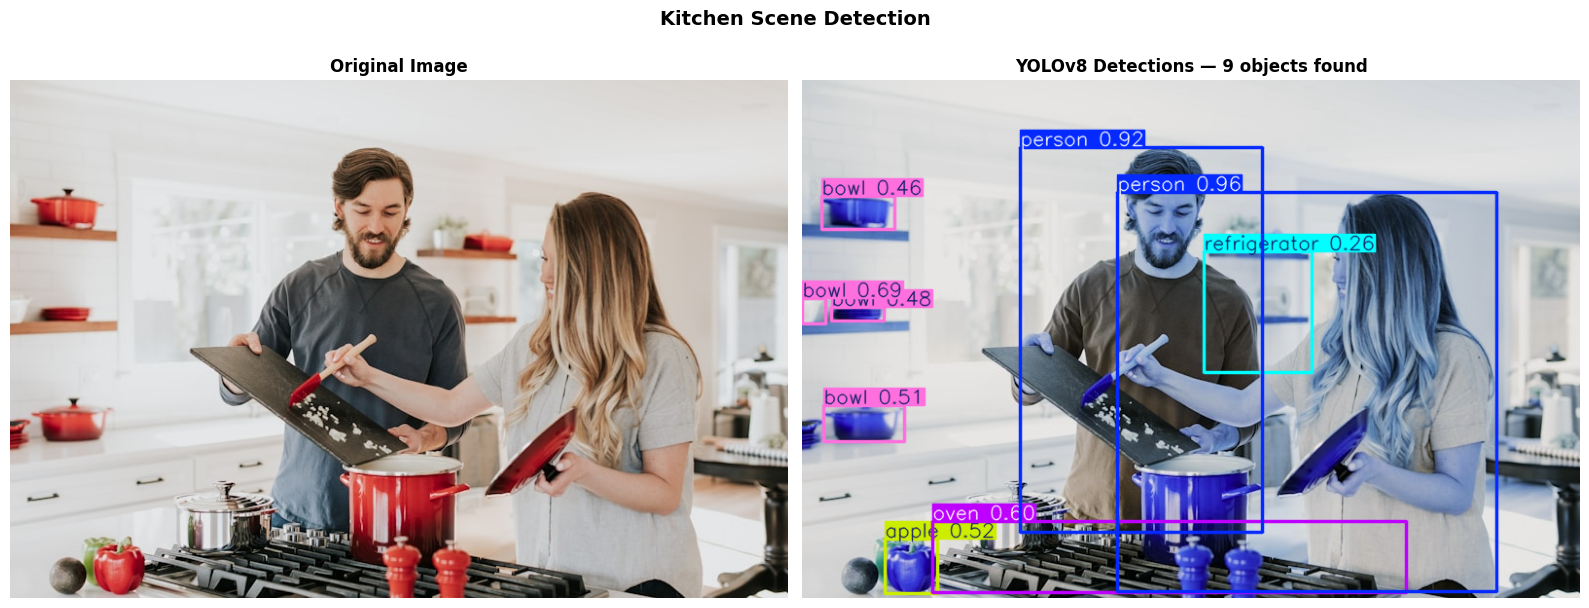


 Detection Summary — Kitchen Scene Detection
Total objects detected: 9
Objects found:
  bowl: 4
  person: 2
  oven: 1
  apple: 1
  refrigerator: 1


In [7]:
# Test 3: Kitchen/Food Scene
# Testing indoors — expect food, furniture, appliances
results3 = detect_and_display(
    "https://images.unsplash.com/photo-1556909114-f6e7ad7d3136?w=800",
    title="Kitchen Scene Detection"
)

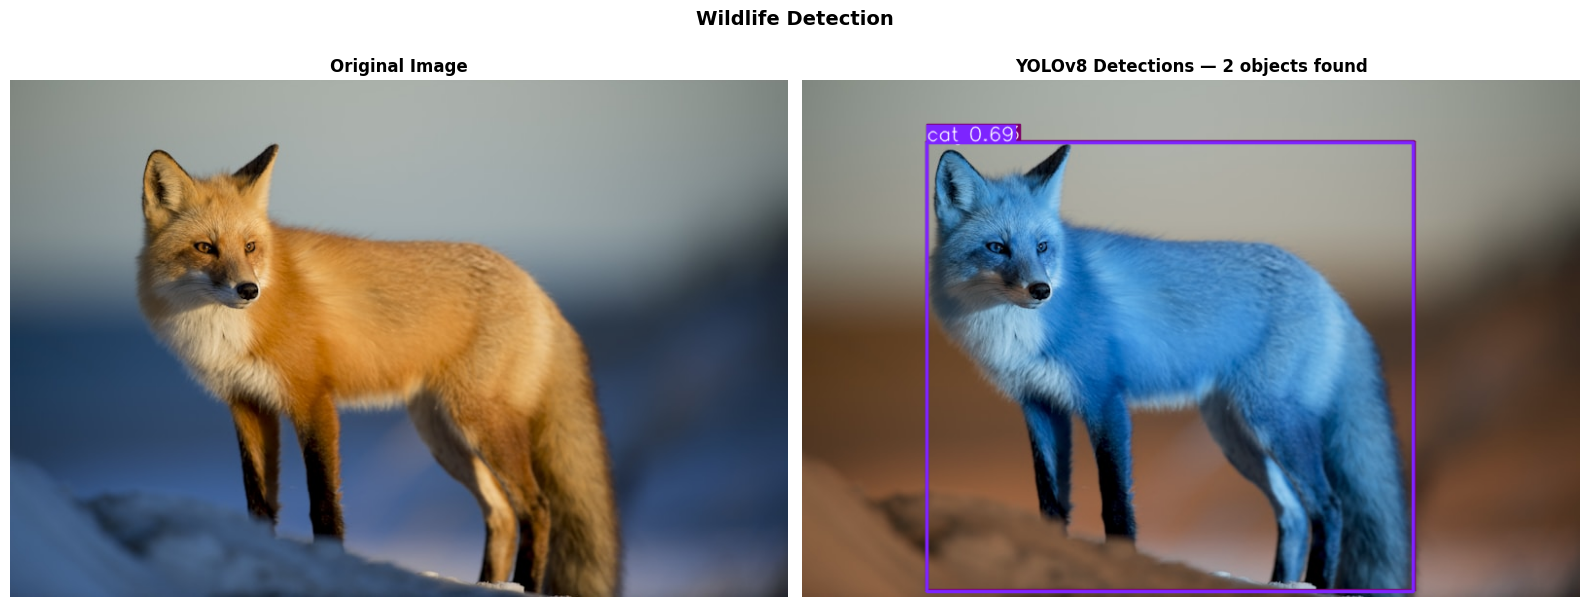


 Detection Summary — Wildlife Detection
Total objects detected: 2
Objects found:
  cat: 1
  dog: 1


In [8]:
# Test 4: Animals
# Testing on wildlife — expect animals
results4 = detect_and_display(
    "https://images.unsplash.com/photo-1474511320723-9a56873867b5?w=800",
    title="Wildlife Detection"
)

In [9]:
#  Imports needed for the app
import gradio as gr
from PIL import Image
import numpy as np
import cv2
import requests
from io import BytesIO

#  Detection Function
# Takes uploaded image + settings, returns annotated image + summary
def detect_objects(image, confidence, model_size):
    if image is None:
        return None, "Please upload an image first!"

    # Load selected model size
    yolo = YOLO(f'yolov8{model_size}.pt')

    # Convert PIL to numpy
    img_np = np.array(image)

    # Run YOLO detection
    results = yolo(img_np, conf=confidence / 100, verbose=False)

    # Get annotated image with bounding boxes
    annotated     = results[0].plot()
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    # Count detections per class
    boxes      = results[0].boxes
    detections = {}
    for box in boxes:
        cls_name = yolo.names[int(box.cls)]
        detections[cls_name] = detections.get(cls_name, 0) + 1

    # Build summary text
    total = sum(detections.values())
    if total == 0:
        summary = "No objects detected. Try lowering the confidence threshold."
    else:
        summary = f"{total} object(s) detected:\n\n"
        for obj, count in sorted(detections.items(), key=lambda x: -x[1]):
            summary += f"   {obj}: {count}\n"

    return Image.fromarray(annotated_rgb), summary

#  Load example images for quick demo
def load_street():
    img = Image.open(BytesIO(
        requests.get("https://ultralytics.com/images/bus.jpg").content
    )).convert("RGB")
    return detect_objects(img, 25, "l")

def load_sports():
    img = Image.open(BytesIO(
        requests.get("https://ultralytics.com/images/zidane.jpg").content
    )).convert("RGB")
    return detect_objects(img, 25, "l")

#  Build Gradio Interface
with gr.Blocks(title="YOLOv8 Object Detector") as demo:

    gr.Markdown("""
    #  YOLOv8 Object Detector
    Upload any image and detect objects instantly using YOLOv8 trained on COCO (80 classes).
    Works on street scenes, sports, wildlife, kitchen, people and more!
    """)

    with gr.Row():

        #  Left: Controls
        with gr.Column(scale=1):
            input_image = gr.Image(
                type="pil",
                label="Upload Any Image",
                height=320
            )
            confidence = gr.Slider(
                minimum=10,
                maximum=90,
                value=25,
                step=5,
                label="Confidence Threshold (%)"
            )
            model_size = gr.Radio(
                choices=["n", "s", "m", "l"],
                value="l",
                label="Model Size (n=fastest, l=most accurate)"
            )
            detect_btn = gr.Button(
                "Detect Objects",
                variant="primary"
            )

        #  Right: Results
        with gr.Column(scale=1):
            output_image = gr.Image(
                label="Detection Result",
                height=320
            )
            output_text = gr.Textbox(
                label="Detection Summary",
                lines=10
            )

    # Quick Example Buttons
    gr.Markdown("### Try these examples:")
    with gr.Row():
        street_btn = gr.Button(" Street Scene")
        sports_btn = gr.Button(" Sports Scene")

    # ── Event Handlers
    detect_btn.click(
        fn=detect_objects,
        inputs=[input_image, confidence, model_size],
        outputs=[output_image, output_text]
    )
    street_btn.click(
        fn=load_street,
        inputs=None,
        outputs=[output_image, output_text]
    )
    sports_btn.click(
        fn=load_sports,
        inputs=None,
        outputs=[output_image, output_text]
    )

# Launch
demo.launch(share=True, debug=False, show_error=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://377ba05dafdb49d0db.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [10]:
#  Save app.py for HuggingFace Spaces
app_code = '''
import gradio as gr
from PIL import Image
import numpy as np
import cv2
import requests
from io import BytesIO
from ultralytics import YOLO

# Load model once at startup
model = YOLO("yolov8l.pt")

def detect_objects(image, confidence, model_size):
    if image is None:
        return None, "Please upload an image first!"

    yolo = YOLO(f"yolov8{model_size}.pt")
    img_np = np.array(image)
    results = yolo(img_np, conf=confidence / 100, verbose=False)
    annotated = results[0].plot()
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    boxes = results[0].boxes
    detections = {}
    for box in boxes:
        cls_name = yolo.names[int(box.cls)]
        detections[cls_name] = detections.get(cls_name, 0) + 1

    total = sum(detections.values())
    if total == 0:
        summary = "No objects detected. Try lowering the confidence threshold."
    else:
        summary = f" {total} object(s) detected:\\n\\n"
        for obj, count in sorted(detections.items(), key=lambda x: -x[1]):
            summary += f"   {obj}: {count}\\n"

    return Image.fromarray(annotated_rgb), summary

def load_street():
    img = Image.open(BytesIO(
        requests.get("https://ultralytics.com/images/bus.jpg").content
    )).convert("RGB")
    return detect_objects(img, 25, "l")

def load_sports():
    img = Image.open(BytesIO(
        requests.get("https://ultralytics.com/images/zidane.jpg").content
    )).convert("RGB")
    return detect_objects(img, 25, "l")

with gr.Blocks(title="YOLOv8 Object Detector") as demo:

    gr.Markdown("""
    # ⚡ YOLOv8 Object Detector
    Upload any image and detect objects instantly using YOLOv8 trained on COCO (80 classes).
    Works on street scenes, sports, wildlife, kitchen, people and more!
    """)

    with gr.Row():
        with gr.Column(scale=1):
            input_image = gr.Image(type="pil", label="Upload Any Image", height=320)
            confidence  = gr.Slider(minimum=10, maximum=90, value=25, step=5, label="Confidence Threshold (%)")
            model_size  = gr.Radio(choices=["n", "s", "m", "l"], value="l", label="Model Size (n=fastest, l=most accurate)")
            detect_btn  = gr.Button("Detect Objects", variant="primary")

        with gr.Column(scale=1):
            output_image = gr.Image(label="Detection Result", height=320)
            output_text  = gr.Textbox(label="Detection Summary", lines=10)

    gr.Markdown("### Try these examples:")
    with gr.Row():
        street_btn = gr.Button(" Street Scene")
        sports_btn = gr.Button(" Sports Scene")

    detect_btn.click(fn=detect_objects, inputs=[input_image, confidence, model_size], outputs=[output_image, output_text])
    street_btn.click(fn=load_street, inputs=None, outputs=[output_image, output_text])
    sports_btn.click(fn=load_sports, inputs=None, outputs=[output_image, output_text])

demo.launch()
'''

with open("app.py", "w") as f:
    f.write(app_code)
print("app.py saved!")

#Save requirements.txt
requirements = """ultralytics
gradio
opencv-python-headless
Pillow
requests
numpy
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)
print("requirements.txt saved!")

app.py saved!
requirements.txt saved!


In [11]:
# Push to HuggingFace Spaces
from huggingface_hub import HfApi, login

# Login
login(token="YOUR_HF_TOKEN_HERE")  #paste your HF token

api = HfApi()

# Create Space
api.create_repo(
    repo_id="yolov8-object-detector",
    repo_type="space",
    space_sdk="gradio",
    exist_ok=True
)

# Upload files
api.upload_file(path_or_fileobj="app.py",          path_in_repo="app.py",          repo_id="samboateng190/yolov8-object-detector", repo_type="space")
api.upload_file(path_or_fileobj="requirements.txt", path_in_repo="requirements.txt", repo_id="samboateng190/yolov8-object-detector", repo_type="space")

print(" App pushed to HuggingFace Spaces!")
print(" Live at: https://huggingface.co/spaces/samboateng190/yolov8-object-detector")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
No files have been modified since last commit. Skipping to prevent empty commit.


 App pushed to HuggingFace Spaces!
 Live at: https://huggingface.co/spaces/samboateng190/yolov8-object-detector


In [13]:
# Run this in Colab to download all saved images
from google.colab import files

files.download('Street_Scene_Detection.png')
files.download('Sports_Scene_Detection.png')
files.download('Kitchen_Scene_Detection.png')
files.download('Wildlife_Detection.png')
files.download('app.py')
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>